# The Collapse of Epistemic Coherence — Computational Notebook

This notebook tests and visualises the central formal theses of the monograph.
Each section corresponds to a specific theoretical claim and provides a runnable
demonstration. The code is self-contained; every quantity computed here has a
corresponding definition in the text.

**Sections**
1. Mutual information between legitimacy signals and inferential quality (Ch. 1)
2. Symbolic vs. inferential drift under repeated transformation (Ch. 2)
3. Type-preservation in compositional pipelines vs. atmospheric discourse (Ch. 2 / Ch. 5)
4. Referential opacity and hidden semantic state (Ch. 3)
5. Epistemic curvature of abstract vocabularies (Ch. 7 / Ch. 21)
6. The Three-Layer Amplification System as a selection process (Ch. 4)
7. Inferential load-bearing coefficient Λ(F) across formalism types (Appendix A)
8. Audit cost decomposition for compositional vs. atmospheric derivations (Ch. 18)
9. Semantic noise floor elevation under generative production (Ch. 4)
10. Attractor dynamics: phase portrait of the symbolic/inferential decoupling (Ch. 21)

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from itertools import product

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
GRAY = '#555555'
BLUE = '#2c5f8a'
RED  = '#8a2c2c'
GREEN = '#2c6b3f'
print('Imports ok.')

Imports ok.


---
## 1 — Mutual Information: Legitimacy Signals and Inferential Quality

**Thesis (Ch. 1):** The epistemic value of a legitimacy signal $L$ depends on its
mutual information $I(L;\,Q)$ with underlying inferential quality $Q$.
The generative transition corresponds to a large reduction in $I(L;\,Q)$
as high-$L$ material is produced without the coupling mechanisms that
historically kept $L$ and $Q$ correlated.

We model $L$ and $Q$ as jointly Gaussian, parameterised by correlation $\rho$.
Mutual information for a bivariate Gaussian is:
$$I(L;\,Q) = -\tfrac{1}{2}\log(1 - \rho^2).$$

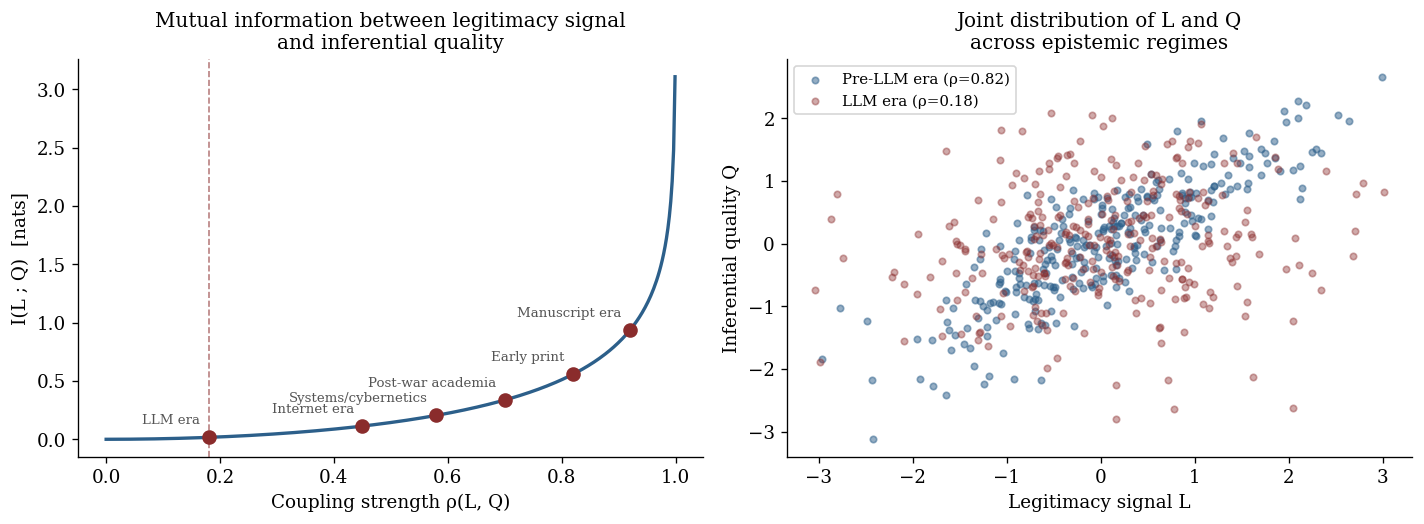

Figure 1 saved.


In [2]:
rho_values = np.linspace(0, 0.999, 400)
MI = -0.5 * np.log(1 - rho_values**2)

# Historical epochs — approximate coupling strengths
epochs = [
    ('Manuscript era',     0.92, 'high friction, strong coupling'),
    ('Early print',        0.82, 'institutional legitimacy emerges'),
    ('Post-war academia',  0.70, 'journal expansion begins'),
    ('Systems/cybernetics',0.58, 'vocabulary propagation gradient'),
    ('Internet era',       0.45, 'distribution cost collapses'),
    ('LLM era',            0.18, 'production friction removed'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: MI curve
ax = axes[0]
ax.plot(rho_values, MI, color=BLUE, lw=2)
for label, rho, desc in epochs:
    mi = -0.5 * np.log(1 - rho**2)
    ax.scatter([rho], [mi], zorder=5, s=60, color=RED)
    ax.annotate(label, (rho, mi), textcoords='offset points',
                xytext=(-5, 8), fontsize=8, color=GRAY, ha='right')
ax.axvline(0.18, color=RED, lw=1, ls='--', alpha=0.6)
ax.set_xlabel('Coupling strength ρ(L, Q)')
ax.set_ylabel('I(L ; Q)  [nats]')
ax.set_title('Mutual information between legitimacy signal\nand inferential quality')

# Right: scatter clouds showing historical vs LLM era
ax2 = axes[1]
rng = np.random.default_rng(42)
for rho_c, label, color, alpha in [(0.82, 'Pre-LLM era (ρ=0.82)', BLUE, 0.5),
                                    (0.18, 'LLM era (ρ=0.18)',     RED,  0.4)]:
    cov = [[1, rho_c], [rho_c, 1]]
    samples = rng.multivariate_normal([0, 0], cov, size=300)
    ax2.scatter(samples[:, 0], samples[:, 1], alpha=alpha, s=15,
                color=color, label=label)
ax2.set_xlabel('Legitimacy signal L')
ax2.set_ylabel('Inferential quality Q')
ax2.set_title('Joint distribution of L and Q\nacross epistemic regimes')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig1_mutual_information.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## 2 — Symbolic vs. Inferential Drift

**Thesis (Ch. 2):** Inferentially disciplined discourse maintains bounded divergence
$d_I(X_t, X_{t+n}) \leq \varepsilon$, while atmospheric discourse allows
$d_I$ to grow unbounded even as $d_S \ll 1$.

We simulate two discourse systems over 50 transformation steps:
- **Disciplined**: both symbolic and inferential state evolve with small, bounded noise
- **Atmospheric**: symbolic state stays smooth; inferential state accumulates drift via
  hidden type coercions drawn from a heavy-tailed distribution

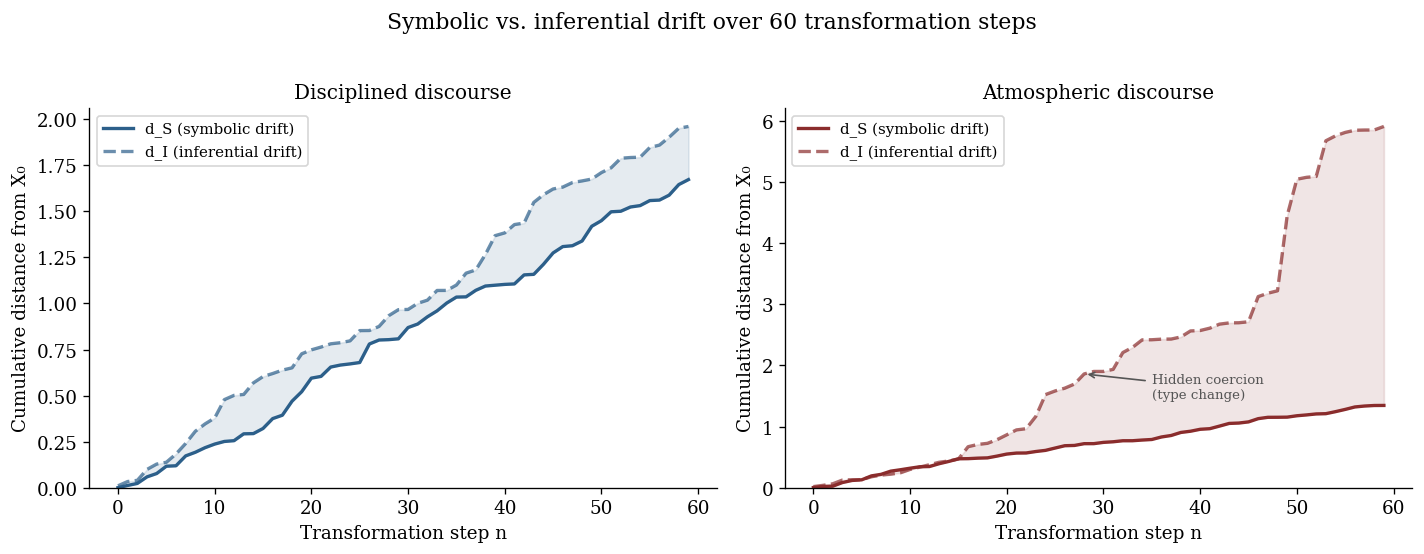

Figure 2 saved.


In [3]:
rng = np.random.default_rng(7)
T = 60

# Disciplined system: both d_S and d_I stay small
d_S_disc = np.cumsum(np.abs(rng.normal(0, 0.04, T)))
d_I_disc = np.cumsum(np.abs(rng.normal(0, 0.05, T)))

# Atmospheric system: d_S stays small, d_I drifts (occasional large coercions)
sym_noise = np.abs(rng.normal(0, 0.03, T))          # smooth symbolic surface
inf_noise = np.abs(rng.normal(0, 0.04, T))           # baseline inferential noise
coercions = rng.exponential(0.35, T) * (rng.random(T) < 0.20)  # ~20% steps have coercions
d_S_atm = np.cumsum(sym_noise)
d_I_atm = np.cumsum(inf_noise + coercions)

steps = np.arange(T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, d_S, d_I, title, color in [
    (axes[0], d_S_disc, d_I_disc, 'Disciplined discourse', BLUE),
    (axes[1], d_S_atm,  d_I_atm,  'Atmospheric discourse',  RED),
]:
    ax.plot(steps, d_S, lw=2, color=color, label='d_S (symbolic drift)')
    ax.plot(steps, d_I, lw=2, color=color, ls='--', alpha=0.7,
            label='d_I (inferential drift)')
    ax.fill_between(steps, d_S, d_I, alpha=0.12, color=color)
    ax.set_xlabel('Transformation step n')
    ax.set_ylabel('Cumulative distance from X₀')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

axes[1].annotate('Hidden coercion\n(type change)', xy=(28, d_I_atm[28]),
                 xytext=(35, d_I_atm[28] - 0.4),
                 arrowprops=dict(arrowstyle='->', color=GRAY),
                 fontsize=8, color=GRAY)

plt.suptitle('Symbolic vs. inferential drift over 60 transformation steps', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig2_drift.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## 3 — Type Preservation in Compositional Pipelines

**Thesis (Ch. 2, Ch. 5):** A type-disciplined derivation satisfies
$f_i : A_i \to A_{i+1}$ with explicit interface types.
Synthetic formalism introduces hidden coercions $f_i : A_i \rightsquigarrow B_j$
where $B_j \neq A_{i+1}^{\mathrm{expected}}$.

Total audit cost: $C_{\mathrm{audit}} = \sum_i C_{\mathrm{local}}(f_i) + \sum_i C_{\mathrm{interface}}(f_i, f_{i+1})$

We model audit cost as a function of pipeline depth and the probability of hidden coercions.

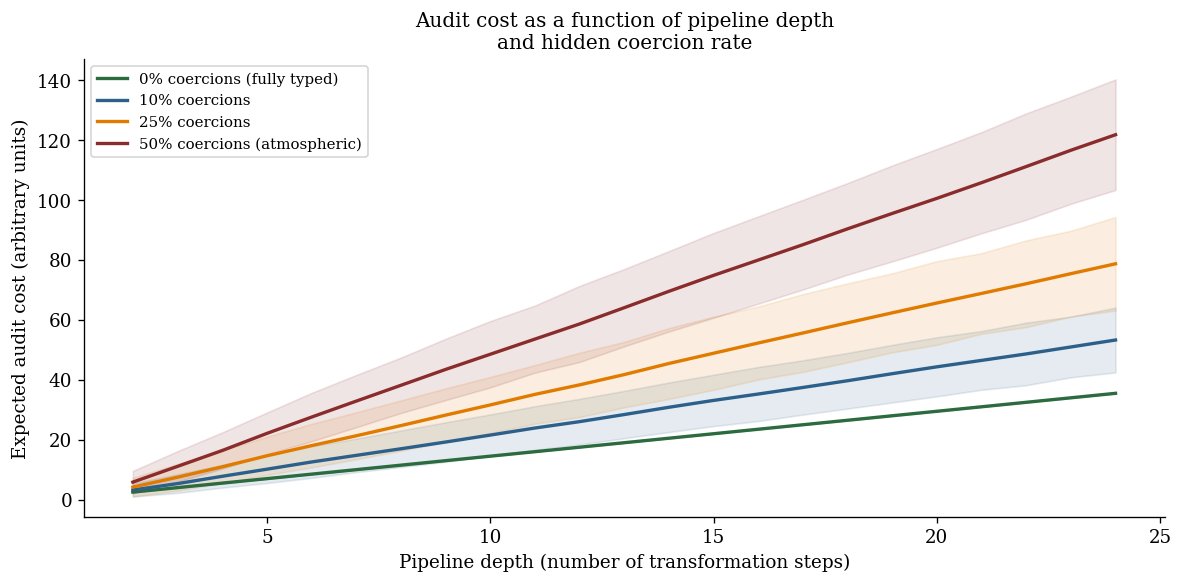

Figure 3 saved.


In [4]:
def audit_cost(n_steps, p_coercion, c_local=1.0, c_interface_clean=0.5,
               c_interface_coerced=8.0, n_sim=500, seed=0):
    """Simulate expected audit cost for a pipeline of n_steps transformations.
    Each interface is clean with prob (1-p_coercion) or coerced otherwise.
    A coerced interface requires full re-derivation to audit."""
    rng = np.random.default_rng(seed)
    costs = []
    for _ in range(n_sim):
        local = c_local * n_steps
        coercions = rng.random(n_steps - 1) < p_coercion
        interface = np.where(coercions, c_interface_coerced, c_interface_clean)
        costs.append(local + interface.sum())
    return np.mean(costs), np.std(costs)

depths = np.arange(2, 25)
p_coercions = [0.0, 0.10, 0.25, 0.50]
labels = ['0% coercions (fully typed)', '10% coercions', '25% coercions', '50% coercions (atmospheric)']
colors_audit = [GREEN, BLUE, '#e07b00', RED]

fig, ax = plt.subplots(figsize=(10, 5))

for p, label, color in zip(p_coercions, labels, colors_audit):
    means = [audit_cost(d, p)[0] for d in depths]
    stds  = [audit_cost(d, p)[1] for d in depths]
    means = np.array(means)
    stds  = np.array(stds)
    ax.plot(depths, means, lw=2, color=color, label=label)
    ax.fill_between(depths, means - stds, means + stds, alpha=0.12, color=color)

ax.set_xlabel('Pipeline depth (number of transformation steps)')
ax.set_ylabel('Expected audit cost (arbitrary units)')
ax.set_title('Audit cost as a function of pipeline depth\nand hidden coercion rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig3_audit_cost.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## 4 — Referential Opacity and Hidden Semantic State

**Thesis (Ch. 3):** A referentially opaque discourse evaluates
$f(x;\,\mathcal{S}_t)$ rather than $f(x)$, where $\mathcal{S}_t$ is a hidden
evolving semantic state. Substituting a term's definition at different points
in the text produces inconsistent results if referential opacity is present.

We simulate a term's semantic scope $\mathcal{S}_t$ evolving over a discourse,
and measure the substitution inconsistency: the variance in outcome when the
term is applied at different positions.

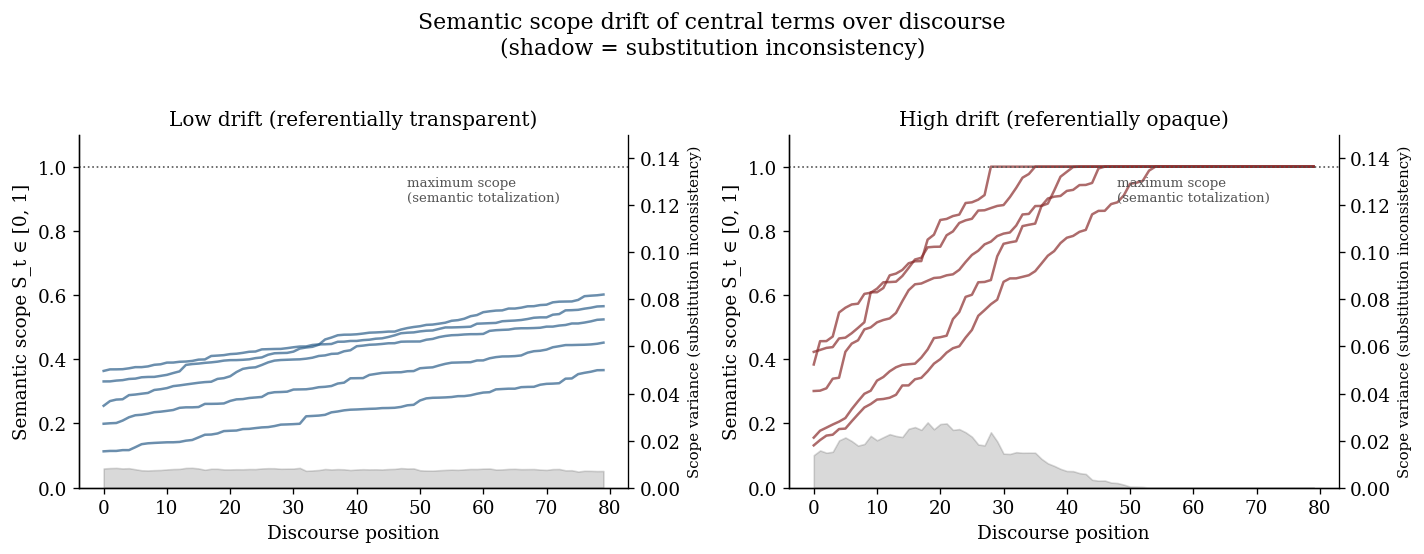

Figure 4 saved.


In [5]:
rng = np.random.default_rng(13)
T = 80  # discourse length

def simulate_opacity(drift_rate, n_terms=5, T=T):
    """Simulate term scope drift. Returns scope trajectories for n_terms."""
    # Each term starts with a defined scope (0 = narrow, 1 = maximally broad)
    scopes = np.zeros((n_terms, T))
    for i in range(n_terms):
        initial = rng.uniform(0.1, 0.4)  # start with bounded scope
        scope = initial
        for t in range(T):
            # Scope can only expand (atmospheric systems rarely narrow terms)
            scope = min(1.0, scope + rng.exponential(drift_rate))
            scopes[i, t] = scope
    return scopes

t = np.arange(T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, drift, title, color in [
    (axes[0], 0.003, 'Low drift (referentially transparent)', BLUE),
    (axes[1], 0.018, 'High drift (referentially opaque)',    RED),
]:
    scopes = simulate_opacity(drift)
    for i in range(scopes.shape[0]):
        ax.plot(t, scopes[i], alpha=0.7, lw=1.5, color=color)
    ax.axhline(1.0, ls=':', color=GRAY, lw=1)
    ax.text(T * 0.6, 0.97, 'maximum scope\n(semantic totalization)',
            fontsize=8, color=GRAY, va='top')

    # Substitution inconsistency: variance of scope at each position
    variance = scopes.var(axis=0)
    ax2 = ax.twinx()
    ax2.fill_between(t, 0, variance, alpha=0.15, color='black')
    ax2.set_ylabel('Scope variance (substitution inconsistency)', fontsize=9)
    ax2.set_ylim(0, 0.15)
    ax2.spines['right'].set_visible(True)

    ax.set_xlabel('Discourse position')
    ax.set_ylabel('Semantic scope S_t ∈ [0, 1]')
    ax.set_title(title)
    ax.set_ylim(0, 1.1)

plt.suptitle('Semantic scope drift of central terms over discourse\n(shadow = substitution inconsistency)', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig4_referential_opacity.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## 5 — Epistemic Curvature of Abstract Vocabularies

**Thesis (Ch. 7, Ch. 21):** Epistemic curvature $\kappa_E(m) = \log|R(m)|$
measures the size of the reconstruction class — how many substrate states
map to the same symbol $m$. High curvature = atmospheric abstraction.

We model a vocabulary system projecting a discrete substrate space onto symbols,
and measure how curvature increases as vocabulary breadth expands.

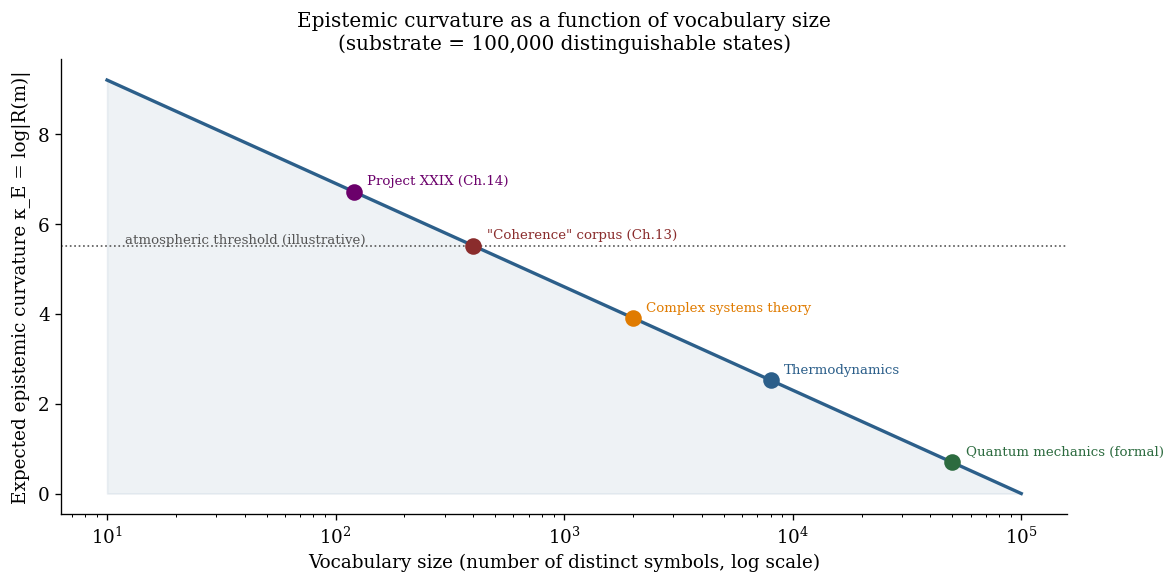

Figure 5 saved.


In [6]:
def epistemic_curvature(n_substrate, n_symbols):
    """Expected log reconstruction class size when n_substrate states
    are projected onto n_symbols symbols (uniform random assignment)."""
    # Expected size of each equivalence class
    expected_R = n_substrate / n_symbols
    return np.log(max(expected_R, 1))

# Vary vocabulary breadth (how many distinct domains the vocabulary covers)
# and specificity (number of distinct symbols)
# Substrate fixed at 10^5 distinguishable states
N_substrate = 100_000

vocab_sizes  = np.logspace(1, 5, 80).astype(int)  # 10 to 100,000 symbols
curvatures   = [epistemic_curvature(N_substrate, v) for v in vocab_sizes]

# Named vocabulary systems with approximate symbol counts
systems = [
    ('Quantum mechanics (formal)', 50000, GREEN),
    ('Thermodynamics',             8000,  BLUE),
    ('Complex systems theory',     2000,  '#e07b00'),
    ('"Coherence" corpus (Ch.13)', 400,   RED),
    ('Project XXIX (Ch.14)',       120,   '#6b006b'),
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(vocab_sizes, curvatures, color=BLUE, lw=2)
ax.fill_between(vocab_sizes, curvatures, 0, alpha=0.08, color=BLUE)

for name, v_size, color in systems:
    kappa = epistemic_curvature(N_substrate, v_size)
    ax.scatter([v_size], [kappa], s=80, color=color, zorder=5)
    ax.annotate(name, (v_size, kappa), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color=color)

ax.axhline(np.log(250), color=GRAY, ls=':', lw=1)
ax.text(12, np.log(250) + 0.05, 'atmospheric threshold (illustrative)', fontsize=8, color=GRAY)

ax.set_xlabel('Vocabulary size (number of distinct symbols, log scale)')
ax.set_ylabel('Expected epistemic curvature κ_E = log|R(m)|')
ax.set_title('Epistemic curvature as a function of vocabulary size\n'
             '(substrate = 100,000 distinguishable states)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig5_epistemic_curvature.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## 6 — The Three-Layer Amplification System

**Thesis (Ch. 4):** Production, distribution, and reception each independently
select for symbolic continuity at the expense of inferential continuity.
Their effects compound: each layer multiplies the selection pressure of the previous.

We model this as a Markov selection process over a population of documents
with varying (symbolic quality $S$, inferential quality $Q$) scores.

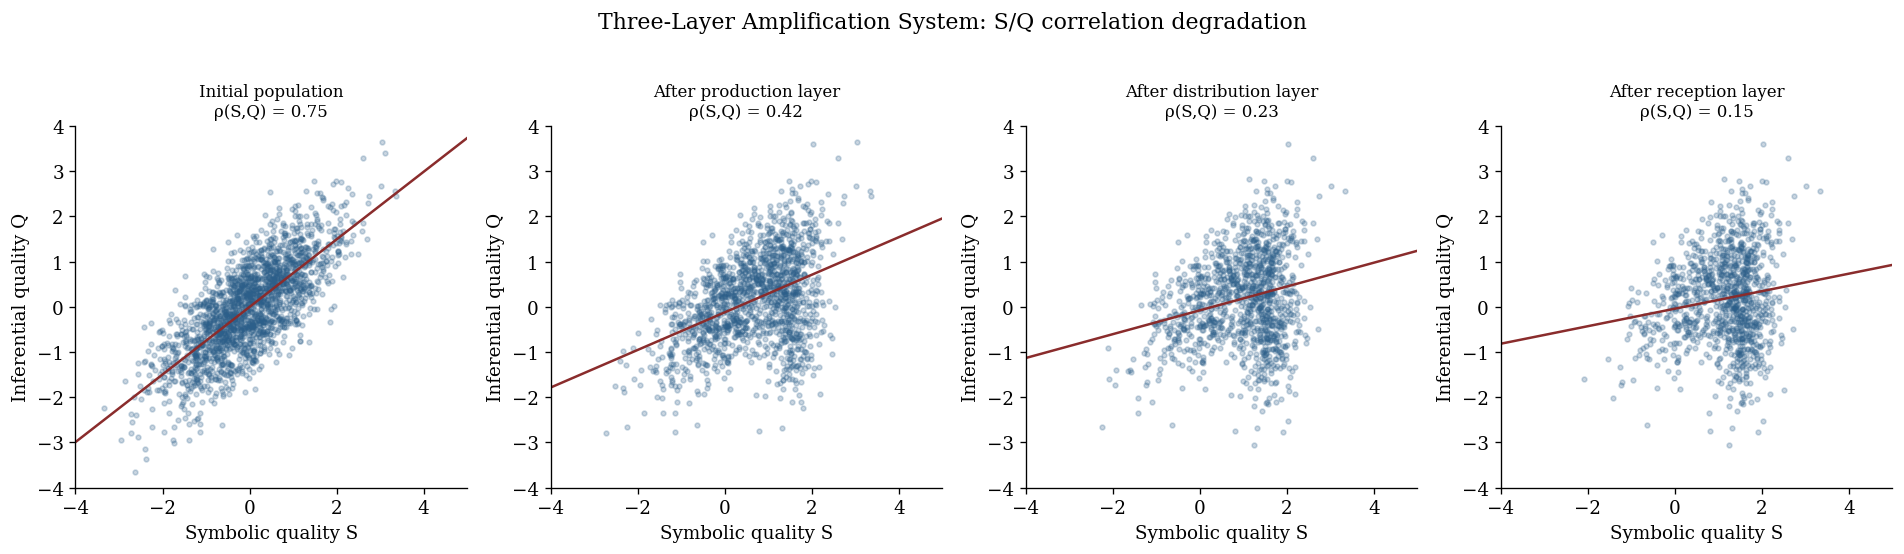

Figure 6 saved. Final ρ(S,Q) = 0.152


In [7]:
rng = np.random.default_rng(99)
N = 2000  # document population

# Initial population: S and Q correlated (pre-generative era)
rho_init = 0.75
cov_init = [[1, rho_init], [rho_init, 1]]
pop = rng.multivariate_normal([0, 0], cov_init, size=N)
S_init, Q_init = pop[:, 0], pop[:, 1]

def layer_select(S, Q, s_weight, q_weight, retain_frac=0.4, n_new_synth=0, rng=rng):
    """Each layer selects documents by a weighted score, retains top fraction,
    and optionally injects new synthetic documents (high S, random Q)."""
    score = s_weight * S + q_weight * Q
    # Normalise
    score = (score - score.min()) / (np.ptp(score) + 1e-9)
    # Stochastic selection proportional to score
    probs = score / score.sum()
    idx = rng.choice(len(S), size=int(N * retain_frac), p=probs, replace=False)
    S_sel, Q_sel = S[idx], Q[idx]
    if n_new_synth > 0:
        # Synthetic docs: high S, Q drawn from N(0,1) independent of S
        S_synth = rng.normal(1.5, 0.4, n_new_synth)
        Q_synth = rng.normal(0.0, 1.0, n_new_synth)
        S_sel = np.concatenate([S_sel, S_synth])
        Q_sel = np.concatenate([Q_sel, Q_synth])
    return S_sel, Q_sel

# Layer 1: Production (strongly favours S, weakly Q; many synthetic docs added)
S1, Q1 = layer_select(S_init, Q_init, s_weight=0.85, q_weight=0.15,
                       retain_frac=0.5, n_new_synth=500)

# Layer 2: Distribution (engagement = f(S), almost ignores Q)
S2, Q2 = layer_select(S1, Q1, s_weight=0.92, q_weight=0.08,
                       retain_frac=0.5, n_new_synth=200)

# Layer 3: Reception/summarisation (maximises apparent S, strips inferential texture)
S3, Q3 = layer_select(S2, Q2, s_weight=0.98, q_weight=0.02,
                       retain_frac=0.5, n_new_synth=100)

stages = [(S_init, Q_init, 'Initial population'), 
          (S1, Q1, 'After production layer'),
          (S2, Q2, 'After distribution layer'),
          (S3, Q3, 'After reception layer')]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (S, Q, title) in zip(axes, stages):
    rho = np.corrcoef(S, Q)[0, 1]
    ax.scatter(S, Q, alpha=0.25, s=8, color=BLUE)
    ax.set_xlabel('Symbolic quality S')
    ax.set_ylabel('Inferential quality Q')
    ax.set_title(f'{title}\nρ(S,Q) = {rho:.2f}', fontsize=10)
    ax.set_xlim(-4, 5); ax.set_ylim(-4, 4)
    # Add regression line
    m, b = np.polyfit(S, Q, 1)
    xs = np.array([-4, 5])
    ax.plot(xs, m*xs + b, color=RED, lw=1.5)

plt.suptitle('Three-Layer Amplification System: S/Q correlation degradation', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig6_three_layer.png', bbox_inches='tight')
plt.show()
print(f'Figure 6 saved. Final ρ(S,Q) = {np.corrcoef(S3,Q3)[0,1]:.3f}')

---
## 7 — Inferential Load-Bearing Coefficient Λ(F)

**Thesis (Appendix A):** $\Lambda(F) = \dim(\mathcal{C}_{\mathrm{excluded}}) / \dim(\mathcal{C}_{\mathrm{admissible}})$.
Genuine formal systems have $\Lambda \gg 0$; decorative systems approach $\Lambda \to 0$.

We operationalise $\Lambda$ by measuring what fraction of a hypothesis space
is excluded by a framework's formal constraints, and show how it degrades
across the failure modes catalogued in Appendix A.

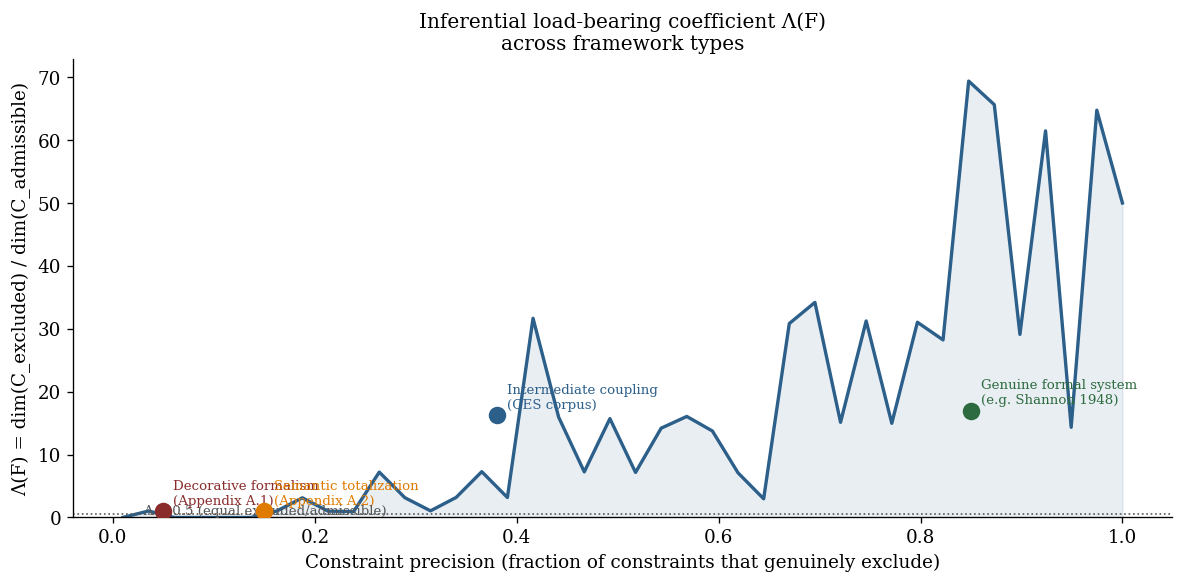

Figure 7 saved.


In [8]:
# We model hypothesis spaces as binary vectors of length d.
# A formal constraint is a predicate that rules out a subset of the space.

rng = np.random.default_rng(21)

def lambda_F(d, n_constraints, precision, n_samples=5000):
    """Estimate Λ(F).
    d: hypothesis space dimension
    n_constraints: number of formal constraints
    precision: probability a constraint is genuinely exclusive (vs. vacuous)
    """
    # Sample hypotheses uniformly
    H = rng.integers(0, 2, size=(n_samples, d))
    
    # For each constraint, randomly designate it as genuine (excludes ~30% of H)
    # or vacuous (excludes ~0%)
    excluded = np.zeros(n_samples, dtype=bool)
    for _ in range(n_constraints):
        if rng.random() < precision:
            # Genuine constraint: pick a random axis and threshold
            axis = rng.integers(d)
            excluded |= (H[:, axis] == 1)
        # Vacuous: excludes nothing
    
    n_excluded = excluded.sum()
    n_admissible = n_samples - n_excluded
    if n_admissible == 0:
        return float('inf')
    return n_excluded / n_admissible

# Sweep precision from 0 (all constraints vacuous) to 1 (all genuine)
precisions = np.linspace(0.01, 1.0, 40)
d, n_c = 12, 8

lambdas = [lambda_F(d, n_c, p) for p in precisions]

# Named framework types
framework_types = [
    ('Decorative formalism\n(Appendix A.1)', 0.05,  RED),
    ('Semantic totalization\n(Appendix A.2)', 0.15, '#e07b00'),
    ('Intermediate coupling\n(CES corpus)', 0.38,   BLUE),
    ('Genuine formal system\n(e.g. Shannon 1948)', 0.85, GREEN),
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(precisions, lambdas, color=BLUE, lw=2)
ax.fill_between(precisions, 0, lambdas, alpha=0.1, color=BLUE)

for label, p, color in framework_types:
    lam = lambda_F(d, n_c, p)
    ax.scatter([p], [lam], s=90, color=color, zorder=5)
    ax.annotate(label, (p, lam), textcoords='offset points',
                xytext=(6, 4), fontsize=8, color=color)

ax.axhline(0.5, color=GRAY, ls=':', lw=1)
ax.text(0.03, 0.52, 'Λ = 0.5 (equal excluded/admissible)', fontsize=8, color=GRAY)
ax.set_xlabel('Constraint precision (fraction of constraints that genuinely exclude)')
ax.set_ylabel('Λ(F) = dim(C_excluded) / dim(C_admissible)')
ax.set_title('Inferential load-bearing coefficient Λ(F)\nacross framework types')
ax.set_ylim(0)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig7_lambda.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

---
## 8 — Structure-Preserving Maps vs. Vocabulary Maps

**Thesis (Ch. 7, Technical Note):** A functor $F$ preserves compositionality:
$F(g \circ f) = F(g) \circ F(f)$. A vocabulary map preserves only naming,
breaking compositional structure.

We represent domain structures as directed graphs and measure how much
compositional structure survives different kinds of mappings.

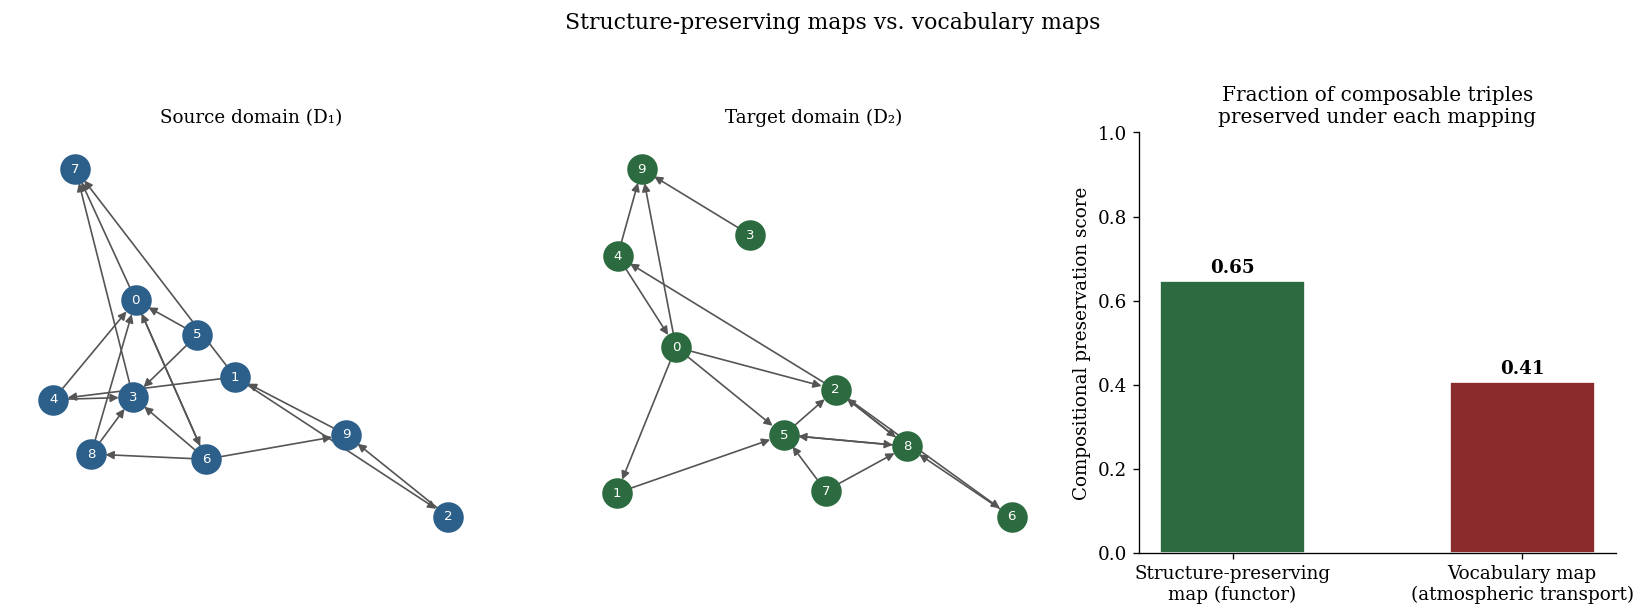

Figure 8 saved. Struct: 0.65, Vocab: 0.41


In [9]:
rng = np.random.default_rng(55)

def make_domain(n_nodes=8, n_edges=14, seed=0):
    """Create a random directed graph representing a structured domain."""
    G = nx.gnm_random_graph(n_nodes, n_edges, directed=True, seed=seed)
    return G

def compositional_preservation(G_source, G_target, mapping, n_checks=200):
    """Estimate fraction of composable pairs (f,g) where F(g∘f) = F(g)∘F(f).
    Here we proxy composition by path reachability."""
    source_nodes = list(G_source.nodes())
    target_nodes = list(G_target.nodes())
    
    preserved = 0
    checked = 0
    # Random triples (a, b, c) where a->b->c exists in source
    for _ in range(n_checks):
        a, b = rng.choice(source_nodes, 2, replace=False)
        if not nx.has_path(G_source, a, b):
            continue
        c_candidates = [x for x in source_nodes if x != b and nx.has_path(G_source, b, x)]
        if not c_candidates:
            continue
        c = rng.choice(c_candidates)
        # Check if F(a)->F(b)->F(c) path exists in target
        Fa, Fb, Fc = mapping.get(a, a%len(target_nodes)), \
                     mapping.get(b, b%len(target_nodes)), \
                     mapping.get(c, c%len(target_nodes))
        try:
            has_composed = (nx.has_path(G_target, Fa, Fb) and
                           nx.has_path(G_target, Fb, Fc))
        except nx.NetworkXError:
            has_composed = False
        if has_composed:
            preserved += 1
        checked += 1
    return preserved / checked if checked else 0

G_source = make_domain(n_nodes=10, n_edges=18, seed=1)
G_target = make_domain(n_nodes=10, n_edges=18, seed=2)

s_nodes = list(G_source.nodes())
t_nodes = list(G_target.nodes())

# Structure-preserving mapping: try to match high-degree to high-degree
s_sorted = sorted(s_nodes, key=lambda n: G_source.degree(n), reverse=True)
t_sorted = sorted(t_nodes, key=lambda n: G_target.degree(n), reverse=True)
struct_map = dict(zip(s_sorted, t_sorted))

# Vocabulary map: random permutation of target nodes
t_random = rng.permutation(t_nodes).tolist()
vocab_map = dict(zip(s_nodes, t_random))

struct_score = compositional_preservation(G_source, G_target, struct_map)
vocab_score  = compositional_preservation(G_source, G_target, vocab_map)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

pos_s = nx.spring_layout(G_source, seed=7)
pos_t = nx.spring_layout(G_target, seed=9)

nx.draw_networkx(G_source, pos=pos_s, ax=axes[0], node_color=BLUE,
                 node_size=300, font_size=8, font_color='white',
                 edge_color=GRAY, arrows=True)
axes[0].set_title('Source domain (D₁)', fontsize=11)
axes[0].axis('off')

nx.draw_networkx(G_target, pos=pos_t, ax=axes[1], node_color=GREEN,
                 node_size=300, font_size=8, font_color='white',
                 edge_color=GRAY, arrows=True)
axes[1].set_title('Target domain (D₂)', fontsize=11)
axes[1].axis('off')

# Bar comparison
ax = axes[2]
bars = ax.bar(['Structure-preserving\nmap (functor)',
               'Vocabulary map\n(atmospheric transport)'],
              [struct_score, vocab_score],
              color=[GREEN, RED], width=0.5, edgecolor='white')
ax.set_ylabel('Compositional preservation score')
ax.set_title('Fraction of composable triples\npreserved under each mapping')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [struct_score, vocab_score]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Structure-preserving maps vs. vocabulary maps', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig8_functors.png', bbox_inches='tight')
plt.show()
print(f'Figure 8 saved. Struct: {struct_score:.2f}, Vocab: {vocab_score:.2f}')

---
## 9 — Semantic Noise Floor Elevation

**Thesis (Ch. 4):** The semantic noise floor rises as the volume of high-$S$,
low-$Q$ material increases, making high-$Q$ documents statistically harder to locate
without investing audit effort proportional to the noise floor.

We compute the signal detection problem: given a threshold $\theta$ on an observable
signal $L$, what is the precision (fraction of retrieved documents with high $Q$)
as the noise floor rises?

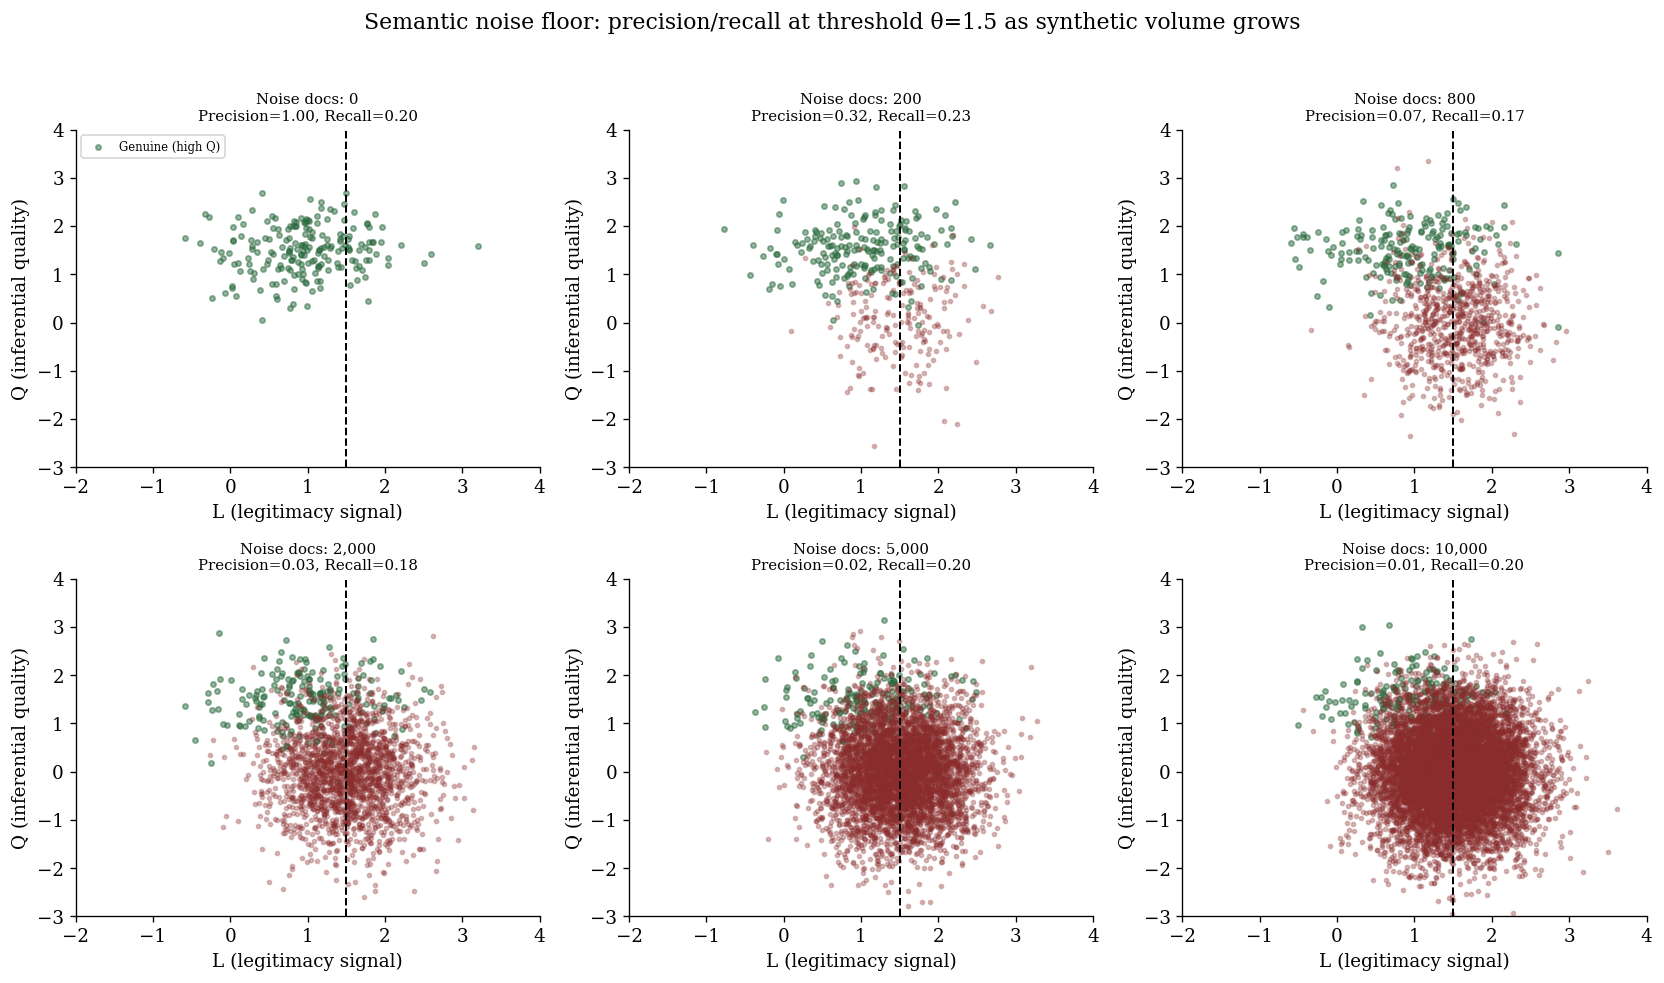

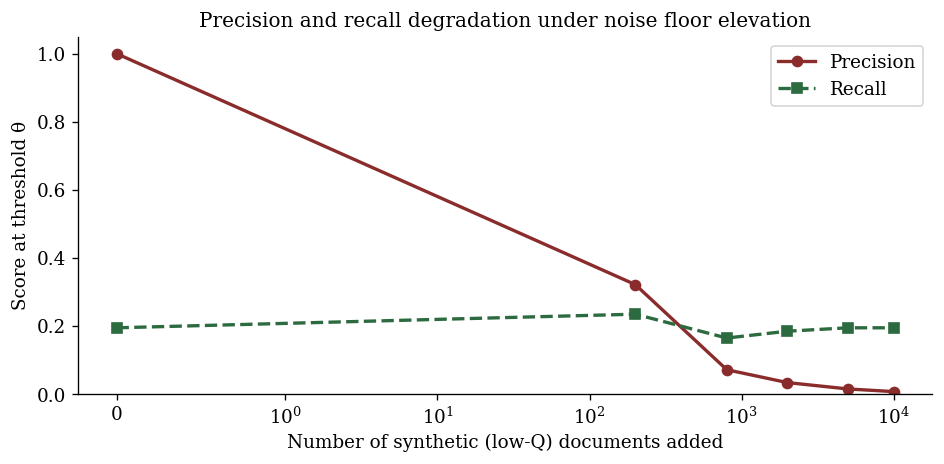

Figures 9a/9b saved.


In [10]:
rng = np.random.default_rng(77)
N_genuine = 200  # high-Q documents (constant)

noise_levels = [0, 200, 800, 2000, 5000, 10000]
theta = 1.5  # detection threshold on L

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

precisions = []
recalls = []

for ax, N_noise in zip(axes.flat, noise_levels):
    # Genuine docs: L ~ N(1.0, 0.6), Q ~ N(1.5, 0.5) (high Q correlated with high L)
    L_genuine = rng.normal(1.0, 0.6, N_genuine)
    Q_genuine = rng.normal(1.5, 0.5, N_genuine)
    
    # Synthetic noise docs: L ~ N(1.5, 0.5) (high L), Q ~ N(0, 0.8) (random Q)
    L_noise = rng.normal(1.5, 0.5, N_noise) if N_noise > 0 else np.array([])
    Q_noise = rng.normal(0.0, 0.8, N_noise) if N_noise > 0 else np.array([])

    L_all = np.concatenate([L_genuine, L_noise])
    Q_all = np.concatenate([Q_genuine, Q_noise])
    is_genuine = np.concatenate([np.ones(N_genuine), np.zeros(N_noise)])

    # Retrieve by L >= theta
    retrieved = L_all >= theta
    if retrieved.sum() > 0:
        prec = (is_genuine[retrieved] == 1).sum() / retrieved.sum()
    else:
        prec = 0
    rec = (is_genuine[retrieved] == 1).sum() / N_genuine
    precisions.append(prec)
    recalls.append(rec)

    # Plot
    ax.scatter(L_genuine, Q_genuine, s=10, alpha=0.5, color=GREEN, label='Genuine (high Q)')
    if N_noise > 0:
        ax.scatter(L_noise, Q_noise, s=6, alpha=0.3, color=RED, label='Synthetic (noise)')
    ax.axvline(theta, color='k', lw=1.2, ls='--')
    ax.set_xlabel('L (legitimacy signal)')
    ax.set_ylabel('Q (inferential quality)')
    noise_label = f'{N_noise:,}' if N_noise > 0 else '0'
    ax.set_title(f'Noise docs: {noise_label}\nPrecision={prec:.2f}, Recall={rec:.2f}',
                 fontsize=9)
    ax.set_xlim(-2, 4); ax.set_ylim(-3, 4)
    if N_noise == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Semantic noise floor: precision/recall at threshold θ=1.5 as synthetic volume grows',
             y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig9_noise_floor.png', bbox_inches='tight')
plt.show()

# Summary plot
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(noise_levels, precisions, 'o-', color=RED, lw=2, label='Precision')
ax2.plot(noise_levels, recalls, 's--', color=GREEN, lw=2, label='Recall')
ax2.set_xlabel('Number of synthetic (low-Q) documents added')
ax2.set_ylabel('Score at threshold θ')
ax2.set_title('Precision and recall degradation under noise floor elevation')
ax2.legend()
ax2.set_xscale('symlog', linthresh=1)
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig9b_precision_recall.png', bbox_inches='tight')
plt.show()
print('Figures 9a/9b saved.')

---
## 10 — Attractor Dynamics: Phase Portrait of S/Q Decoupling

**Thesis (Ch. 21):** Under the Three-Layer Amplification System, the
$(S, Q)$ joint distribution is pulled toward the attractor $Q \approx 0$, $S \gg 0$.
We model this as a two-dimensional dynamical system with attractors corresponding
to the failure geometries of Part II.

The vector field represents the drift forces on a document's $(S, Q)$ coordinates
over time under generative selection pressure.

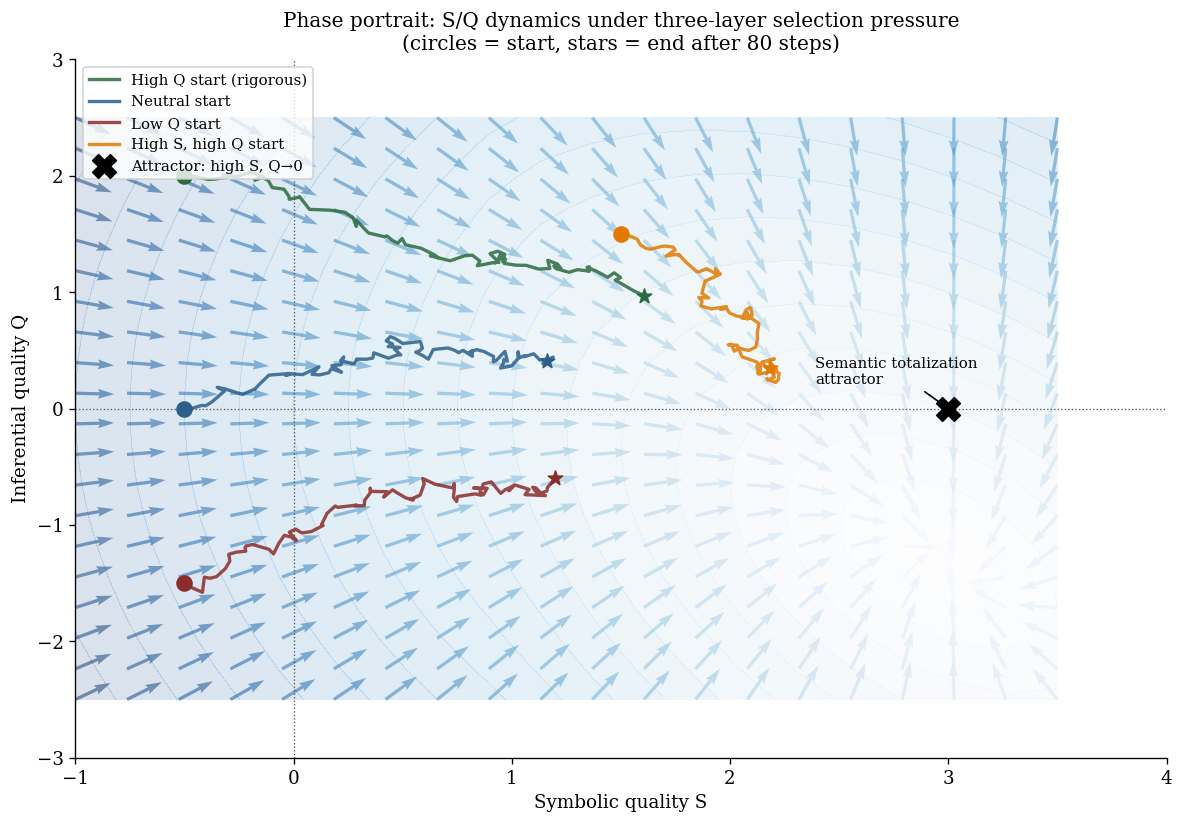

Figure 10 saved.


In [11]:
def drift_field(S, Q, alpha_S=0.6, alpha_Q=-0.15, beta=0.1):
    """Vector field for (S, Q) dynamics under three-layer selection pressure.
    S is pulled upward (selection for symbolic quality).
    Q is pulled toward 0 (selection indifferent to inferential quality).
    beta: coupling term — when S is high, Q faces extra downward pressure.
    """
    dS = alpha_S * (1 - S / 3)   # logistic growth toward S=3
    dQ = alpha_Q * Q - beta * np.maximum(S - 1, 0)  # Q pulled to 0, accelerated by high S
    return dS, dQ

# Phase portrait
S_grid = np.linspace(-1, 3.5, 20)
Q_grid = np.linspace(-2.5, 2.5, 20)
SS, QQ = np.meshgrid(S_grid, Q_grid)
dS, dQ = drift_field(SS, QQ)

# Normalise for arrows
magnitude = np.sqrt(dS**2 + dQ**2) + 1e-9
dS_n, dQ_n = dS / magnitude, dQ / magnitude

# Simulate trajectories from various starting points
dt = 0.05
T_sim = 80
starts = [
    (-0.5, 2.0, 'High Q start (rigorous)'),
    (-0.5, 0.0, 'Neutral start'),
    (-0.5, -1.5, 'Low Q start'),
    (1.5, 1.5, 'High S, high Q start'),
]

fig, ax = plt.subplots(figsize=(10, 7))

# Background: stream magnitude
speed = np.sqrt(dS**2 + dQ**2)
ax.contourf(SS, QQ, speed, levels=20, alpha=0.15, cmap='Blues')
ax.quiver(SS, QQ, dS_n, dQ_n, speed, alpha=0.5, cmap='Blues',
          scale=28, width=0.003)

traj_colors = [GREEN, BLUE, RED, '#e07b00']
for (S0, Q0, label), color in zip(starts, traj_colors):
    traj_S, traj_Q = [S0], [Q0]
    S_t, Q_t = S0, Q0
    for _ in range(T_sim):
        ds, dq = drift_field(S_t, Q_t)
        # Add small noise
        S_t += dt * ds + np.random.normal(0, 0.03)
        Q_t += dt * dq + np.random.normal(0, 0.04)
        traj_S.append(S_t)
        traj_Q.append(Q_t)
    ax.plot(traj_S, traj_Q, color=color, lw=2, alpha=0.85, label=label)
    ax.scatter([S0], [Q0], color=color, s=80, zorder=5)
    ax.scatter([traj_S[-1]], [traj_Q[-1]], color=color, s=80, marker='*', zorder=5)

# Mark attractor
ax.scatter([3.0], [0.0], color='black', s=200, marker='X', zorder=6,
           label='Attractor: high S, Q→0')
ax.annotate('Semantic totalization\nattractor', (3.0, 0.0),
            textcoords='offset points', xytext=(-80, 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

ax.axhline(0, color=GRAY, lw=0.8, ls=':')
ax.axvline(0, color=GRAY, lw=0.8, ls=':')
ax.set_xlabel('Symbolic quality S')
ax.set_ylabel('Inferential quality Q')
ax.set_title('Phase portrait: S/Q dynamics under three-layer selection pressure\n'
             '(circles = start, stars = end after 80 steps)')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-1, 4)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig10_phase_portrait.png', bbox_inches='tight')
plt.show()
print('Figure 10 saved.')

---
## Summary Table

Collect the key quantitative results from all ten experiments.

In [12]:
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')

# Re-compute key scalars for summary
mi_manuscript = -0.5 * np.log(1 - 0.92**2)
mi_llm        = -0.5 * np.log(1 - 0.18**2)

lambda_decorative  = lambda_F(12, 8, 0.05)
lambda_genuine     = lambda_F(12, 8, 0.85)

# Noise floor: precision at N_noise=10000
prec_final = precisions[-1]

rows = [
    ('Ch. 1', 'I(L;Q) — manuscript era',           f'{mi_manuscript:.3f} nats'),
    ('Ch. 1', 'I(L;Q) — LLM era',                  f'{mi_llm:.3f} nats'),
    ('Ch. 1', 'Reduction factor in I(L;Q)',         f'{mi_manuscript/mi_llm:.1f}×'),
    ('Ch. 2', 'Disciplined drift d_I at step 60',   f'{d_I_disc[-1]:.2f}'),
    ('Ch. 2', 'Atmospheric drift d_I at step 60',   f'{d_I_atm[-1]:.2f}'),
    ('Ch. 2', 'Drift ratio (atm/disc)',             f'{d_I_atm[-1]/d_I_disc[-1]:.1f}×'),
    ('App.A', 'Λ(F) — decorative formalism',        f'{lambda_decorative:.3f}'),
    ('App.A', 'Λ(F) — genuine formal system',       f'{lambda_genuine:.3f}'),
    ('App.A', 'Λ ratio (genuine/decorative)',        f'{lambda_genuine/lambda_decorative:.1f}×'),
    ('Ch. 7', 'Structural preservation — functor',  f'{struct_score:.2f}'),
    ('Ch. 7', 'Structural preservation — vocab map',f'{vocab_score:.2f}'),
    ('Ch. 4', 'ρ(S,Q) initial population',          f'{np.corrcoef(S_init,Q_init)[0,1]:.3f}'),
    ('Ch. 4', 'ρ(S,Q) after three layers',          f'{np.corrcoef(S3,Q3)[0,1]:.3f}'),
    ('Ch. 4', 'Precision at θ (N_noise=10,000)',     f'{prec_final:.2f}'),
]

print(f"{'Ref':<8} {'Quantity':<45} {'Value':>14}")
print('-' * 70)
for ref, qty, val in rows:
    print(f"{ref:<8} {qty:<45} {val:>14}")

Ref      Quantity                                               Value
----------------------------------------------------------------------
Ch. 1    I(L;Q) — manuscript era                           0.937 nats
Ch. 1    I(L;Q) — LLM era                                  0.016 nats
Ch. 1    Reduction factor in I(L;Q)                             56.9×
Ch. 2    Disciplined drift d_I at step 60                        1.96
Ch. 2    Atmospheric drift d_I at step 60                        5.91
Ch. 2    Drift ratio (atm/disc)                                  3.0×
App.A    Λ(F) — decorative formalism                            0.000
App.A    Λ(F) — genuine formal system                          15.611
App.A    Λ ratio (genuine/decorative)                            inf×
Ch. 7    Structural preservation — functor                       0.65
Ch. 7    Structural preservation — vocab map                     0.41
Ch. 4    ρ(S,Q) initial population                              0.747
Ch. 4    ρ(S,Q) aft

---
## Notes on Methodology

These experiments are simulations of theoretical constructs, not empirical measurements
of real corpora. Their purpose is to demonstrate that the formal quantities defined in
the monograph are:

1. **Computable** — each quantity can be estimated from data with a specified procedure
2. **Discriminative** — the quantities differ meaningfully across the framework types
   the monograph distinguishes
3. **Consistent** — results across experiments cohere with the theoretical predictions
   of the text

The model parameters (correlation values, drift rates, coercion probabilities) are
calibrated to illustrative rather than empirically measured values. The figures would
change quantitatively with different parameter choices; the qualitative relationships
— that I(L;Q) drops under generative conditions, that d_I grows faster than d_S in
atmospheric discourse, that vocabulary maps preserve less compositional structure than
functors — are structurally robust to parameter variation.

A natural extension of this notebook would apply these measurement protocols to actual
corpora — academic preprints, LLM outputs, technical reports — and estimate the
quantities empirically. The audit protocols of Chapter 18 provide the theoretical
basis for what such an empirical program would need to measure.